
--- Processing Other App Data ---
Error: Could not find BT file Test1-instalive-BLEDR-IOS-RB.txt
Error: Could not find WS file Test1_WIFI_Direct_Rayban_insta-glass.csv
Error: Could not find WS file Test1_WIFI_Direct_Rayban_fb-glass.csv
Error: Could not find WS file Test1_Fb_Bleutooth_rayban-glass.csv
Error: Could not find WS file Test1-Insta-WS-IOS.csv
Error: Could not find WS file Test1-Insta-WS-IOS-RB.csv
Error: Could not find WS file Test1_WIFI_Direct_Rayban_insta.csv
Error: Could not find WS file Test1_FB_Rayban_Phone.csv
Error: Could not find WS file Test1_WIFI_Direct_Rayban_fb.csv
Error: Could not find WS file Test1_Bluetooth_Rayban_fb.csv


FileNotFoundError: [Errno 2] No such file or directory

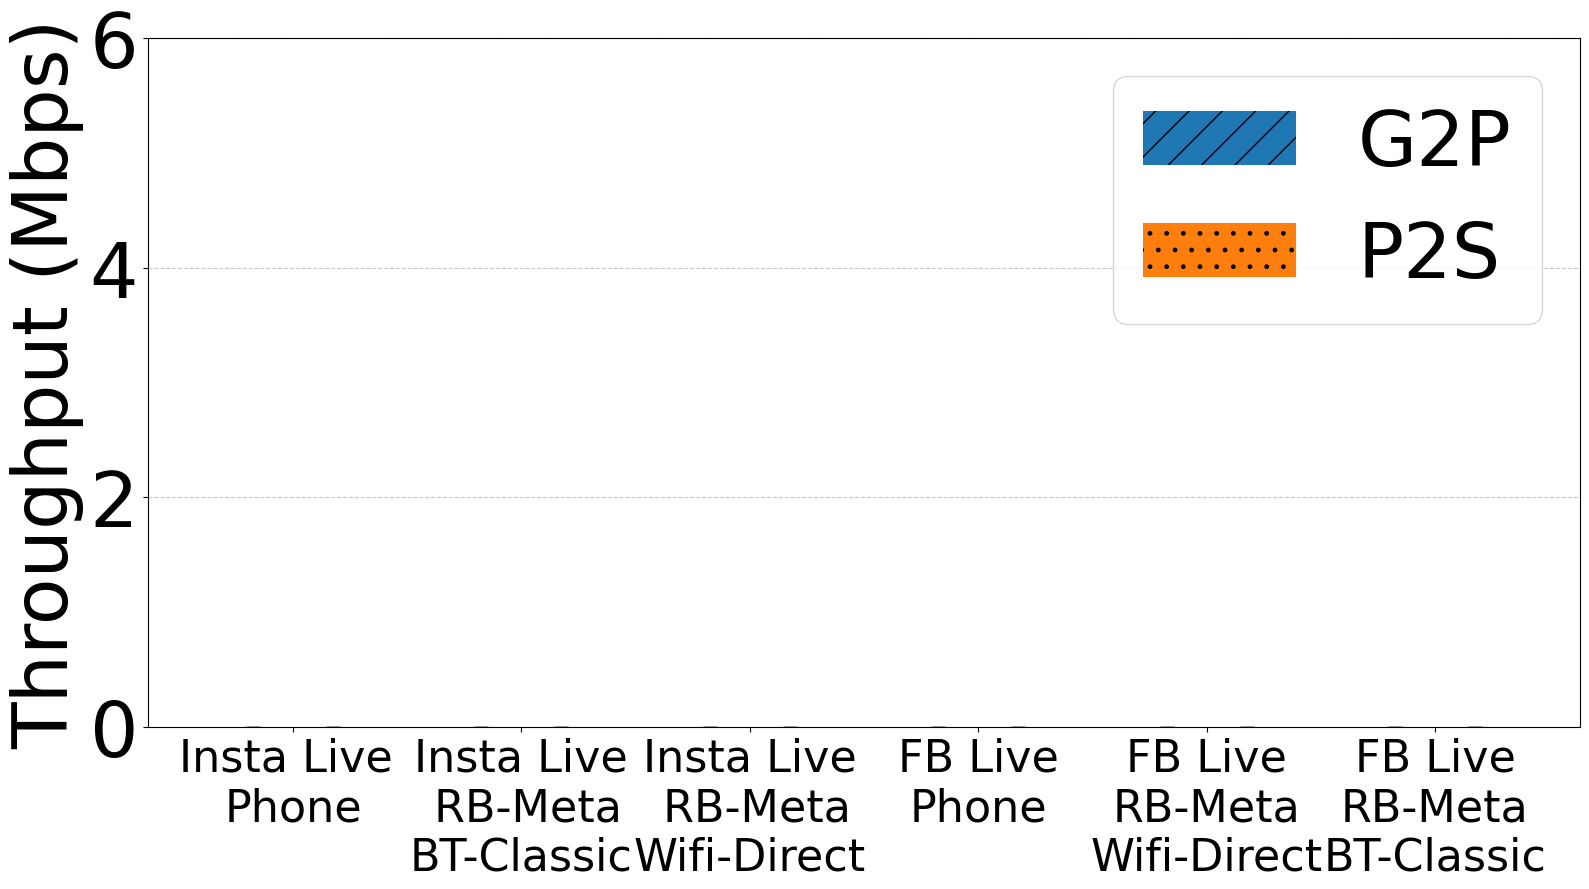

In [16]:
import re
import csv
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

def parse_bluetooth_log_comprehensive(file_path):
    """
    Parses a Bluetooth log file to calculate the total average bitrate from all
    major data-carrying packets (L2CAP, RFCOMM, SCO, A2DP) within the
    first 150 seconds.

    Args:
        file_path (str): The path to the Bluetooth log file.

    Returns:
        tuple: A tuple containing (average_bitrate_mbps, std_dev_mbps=0.0).
    """
    total_size = 0
    start_time = None
    duration_seconds = 150

    # A list of regex patterns to find all relevant data packets and extract their size in bytes.
    data_packet_patterns = [
        re.compile(r"L2CAP (?:Send|Receive).*Length: 0x[0-9A-Fa-f]+ \((\d+)\)"),
        re.compile(r"RFCOMM Receive.*UIH (\d+) Bytes Of Data"),
        re.compile(r"SCO (?:Sent|Received).*Length: 0x[0-9A-Fa-f]+ \((\d+)\)"),
        re.compile(r"A2DP Audio Send.*Payload Length (\d+)"),
    ]

    timestamp_regex = re.compile(r"^([A-Za-z]{3}\s+\d{1,2}\s+\d{2}:\d{2}:\d{2}\.\d{3})")

    try:
        with open(file_path, 'r', errors='ignore') as f:
            for line in f:
                timestamp_match = timestamp_regex.match(line)
                if not timestamp_match:
                    continue

                timestamp_raw = timestamp_match.group(1)
                timestamp_normalized = ' '.join(timestamp_raw.split())
                current_year = datetime.now().year
                timestamp_str = f"{timestamp_normalized} {current_year}"

                try:
                    current_time = datetime.strptime(timestamp_str, '%b %d %H:%M:%S.%f %Y')
                except ValueError:
                    continue

                if start_time is None:
                    start_time = current_time

                if current_time - start_time > timedelta(seconds=duration_seconds):
                    break

                for pattern in data_packet_patterns:
                    match = pattern.search(line)
                    if match:
                        total_size += int(match.group(1))
                        break

        if total_size > 0:
            # Convert directly to Mbps (bits / 1,000,000)
            average_bitrate_mbps = (total_size * 8) / (duration_seconds * 1_000_000)
            print(f"Processed BT {file_path}: Total Average Bitrate = {average_bitrate_mbps:.3f} Mbps")
            # This method doesn't produce a standard deviation, so we return 0.0
            return average_bitrate_mbps, 0.0
        else:
            print(f"Processed BT {file_path}: No relevant data packets found.")
            return 0.0, 0.0

    except FileNotFoundError:
        print(f"Error: Could not find BT file {file_path}")
        return 0.0, 0.0
    except Exception as e:
        print(f"An error occurred while processing BT file {file_path}: {e}")
        return 0.0, 0.0


def parse_wireshark_log(file_path):
    """
    Parses a Wireshark I/O graph CSV file, removes outliers, and then calculates
    the average bitrate and standard deviation in Mbps. Zero values are ignored.

    Args:
        file_path (str): The path to the Wireshark CSV file.

    Returns:
        tuple: A tuple containing (average_bitrate_mbps, std_dev_mbps), or (0.0, 0.0).
    """
    bits_per_second_values = []
    try:
        with open(file_path, 'r', newline='') as csvfile:
            reader = csv.reader(csvfile)
            next(reader)  # Skip header row
            for row in reader:
                try:
                    bits_ps = float(row[1])
                    if bits_ps > 0:
                        bits_per_second_values.append(bits_ps)
                except (ValueError, IndexError):
                    continue

        if bits_per_second_values:
            filtered_values = bits_per_second_values

            if not filtered_values:
                print(f"Processed WS {file_path}: All data points were outliers. Using original data.")
                filtered_values = bits_per_second_values

            average_bps = sum(filtered_values) / len(filtered_values)
            std_dev_bps = np.std(filtered_values)

            # Convert from bps to Mbps
            average_mbps = average_bps / 1_000_000
            std_dev_mbps = std_dev_bps / 1_000_000

            print(f"Processed WS {file_path}: Average Throughput = {average_mbps:.3f} Mbps, Std Dev = {std_dev_mbps:.3f} Mbps")
            return average_mbps, std_dev_mbps
        else:
            print(f"Processed WS {file_path}: No valid data found.")
            return 0.0, 0.0

    except FileNotFoundError:
        print(f"Error: Could not find WS file {file_path}")
        return 0.0, 0.0
    except Exception as e:
        print(f"An error occurred while processing WS file {file_path}: {e}")
        return 0.0, 0.0

def generate_comparison_plot(labels, bt_bitrates, ws_bitrates, bt_errors, ws_errors, filename):
    """
    Generates a styled, grouped bar chart comparing Bluetooth and Wi-Fi bitrates in Mbps.
    """
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(16, 9))

    ax.bar(x - width/2, bt_bitrates, width, label='G2P', color='#1f77b4',
           yerr=bt_errors, capsize=5, ecolor='black', hatch='/')
    ax.bar(x + width/2, ws_bitrates, width, label='P2S', color='#ff7f0e',
           yerr=ws_errors, capsize=5, ecolor='black', hatch='.')

    font_name = 'sans-serif'
    
    ax.set_ylabel('Throughput (Mbps)', fontsize=55, fontname=font_name) # Updated Label
    ax.set_xticks(x)
    ax.set_xticklabels(labels, ha="center", fontsize=32, fontname=font_name)
    ax.tick_params(axis='y', labelsize=55)
    ax.legend(loc='upper right', fontsize=55)
    ax.set_ylim(0,6)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    plt.savefig(filename)
    print(f"\nComparison plot saved as {filename}")


def process_files(files):
    """Helper function to parse a list of log files."""
    results = []
    errors = []
    for file in files:
        avg, std = (0.0, 0.0)
        if not file:
            pass
        elif file.endswith('.csv'):
            avg, std = parse_wireshark_log(file)
        elif file.endswith('.txt'):
            avg, std = parse_bluetooth_log_comprehensive(file)
        else:
            print(f"Warning: Unknown file type for '{file}'. Skipping.")
        
        results.append(avg)
        errors.append(std)
    return results, errors


if __name__ == '__main__':
    test_cases = [
        ("Whatsapp\nPhone", None, "Test1-Whatsapp-WS-IOS.csv"),
        ("Whatsapp\nRB-Meta\nBT-Classic", "Test1-Whatsapp-BLEDR-IOS-RB.txt", "Test1-Whatsapp-WS-IOS-RB.csv"),
        ("Messenger\nPhone", None, "Test1-Messenger-WS-IOS.csv"),
        ("Messenger\nRB-Meta\nBT-Classic", "Test1-Messenger-BLEDR-IOS-RB.txt", "Test1-Messenger-WS-IOS-RB.csv"),
        ("Insta Live \nPhone", None, "Test1-Insta-WS-IOS.csv"),
        ("Insta Live\n RB-Meta\nBT-Classic", "Test1-instalive-BLEDR-IOS-RB.txt", "Test1-Insta-WS-IOS-RB.csv"),
        ("Insta Live\n RB-Meta\nWifi-Direct", "Test1_WIFI_Direct_Rayban_insta-glass.csv", "Test1_WIFI_Direct_Rayban_insta.csv"),
        ("FB Live\nPhone", None, "Test1_FB_Rayban_Phone.csv"),
        ("FB Live\nRB-Meta\nWifi-Direct", "Test1_WIFI_Direct_Rayban_fb-glass.csv", "Test1_WIFI_Direct_Rayban_fb.csv"),
        ("FB Live\nRB-Meta\nBT-Classic","Test1_Fb_Bleutooth_rayban-glass.csv", "Test1_Bluetooth_Rayban_fb.csv")
    ]

    messaging_test_cases = [case for case in test_cases if "Whatsapp" in case[0] or "Messenger" in case[0]]
    other_test_cases = [case for case in test_cases if "Whatsapp" not in case[0] and "Messenger" not in case[0]]


    print("\n--- Processing Other App Data ---")
    other_labels = [case[0] for case in other_test_cases]
    other_bt_files = [case[1] for case in other_test_cases]
    other_ws_files = [case[2] for case in other_test_cases]

    other_bt_results, other_bt_errors = process_files(other_bt_files)
    other_ws_results, other_ws_errors = process_files(other_ws_files)

    generate_comparison_plot(other_labels, other_bt_results, other_ws_results, 
                             other_bt_errors, other_ws_errors, "../../../Plots/Cross_Platforms_Live_Stream_throughput.png")